In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

In [83]:
df = pd.read_csv('../data/bank_fin.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [84]:
df.isna().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

Есть пропуски в признаке balance, есть признаки со значением unknown - тоже обозначение пропусков, посмотрим более детально

In [85]:
for col in df.select_dtypes(include='object').columns:
    if df[col].str.contains('unknown', case=False, na=False).any():
        print(f"В столбце {col} есть 'unknown'")

В столбце job есть 'unknown'
В столбце education есть 'unknown'
В столбце contact есть 'unknown'
В столбце poutcome есть 'unknown'


Вместо пропусков видим неизвестные значения "unknown"

Значения ***unknown*** в признаках ***contact*** и ***poutcome*** заменять не будем, так как они представляют отдельную категорию, а не пропущенные значения.

А вот в признаках ***job*** и ***education*** - заменим

In [86]:
df['balance'] = (
    df['balance']
    .replace({'\$': '', ' ': '', r'\,00': ''}, regex=True)
    .replace('', '0')
    .astype(float)
)

df['balance'].mean().round(3)

np.float64(1529.129)

заменим пропуски на медианное значение

In [87]:
df['balance'] = df['balance'].fillna(df['balance'].median())
df['balance'].mean().round(3)

np.float64(1526.936)

In [88]:
df['balance'].isna().sum()

np.int64(0)

Обработаем пропуски в признаках job и education

In [89]:
df['job'] = df['job'].replace('unknown', np.nan)
df['job'] = df['job'].fillna(df['job'].mode()[0])

df['education'] = df['education'].replace('unknown', np.nan).fillna(df['education'].mode()[0])

In [90]:
most_common_job = df['job'].mode()[0]
most_common_education = df['education'].mode()[0]

df[
    (df['job'] == most_common_job) &
    (df['education'] == most_common_education)
]['balance'].mean().round(3)

np.float64(1598.883)

<Axes: xlabel='balance'>

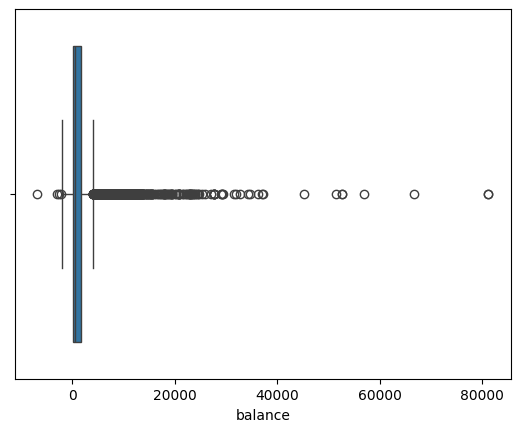

In [ ]:
sns.boxplot(x=df['balance'])

Есть выбросы, обработаем их с помощью метода Тьюки

In [92]:
def tukey_filter(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered = df[(df[column] >= lower) & (df[column] <= upper)]

    return filtered, lower, upper

df, lower_bound, upper_bound = tukey_filter(df, 'balance')

lower_bound, upper_bound

(np.float64(-2241.0), np.float64(4063.0))

Сохраним очищенный файл

In [95]:
df.to_csv('../data/bank_clean.csv', index=False)